In [1]:
# Time Series Forcasting with Prophet
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

import warnings
warnings.filterwarnings("ignore")

plt.style.use('ggplot')
plt.style.use('fivethirtyeight')

def mean_absolute_percentage_error(y_true, y_pred): 
    """Calculates MAPE given y_true and y_pred"""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


In [2]:
MedianHouseholdIncome = pd.read_csv('MedianHouseholdIncome.csv',
                   index_col=[0],
                  parse_dates=[0])
MedianHouseholdIncome.head()

,MEHOINUSNYA672N
observation_date,
1984-01-01,57910
1985-01-01,60100
1986-01-01,62600
1987-01-01,63840
1988-01-01,67470


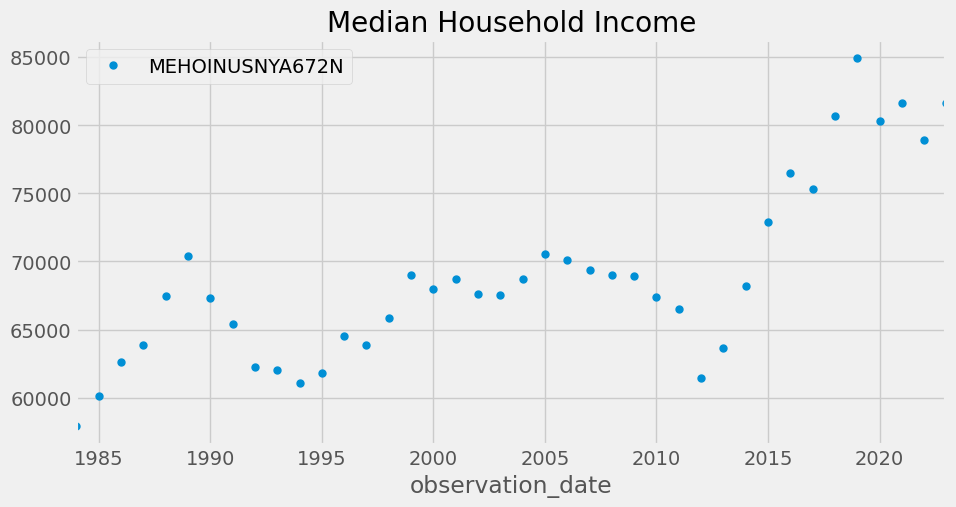

In [3]:
color_pal = sns.color_palette()
MedianHouseholdIncome.plot(style='.',
          figsize=(10, 5),
          ms=10,
          color=color_pal[0],
          title='Median Household Income')
plt.show()

In [4]:
NYCMultifamily = pd.read_excel('NYCMultifamily.xlsx',
                   index_col=[0],
                  parse_dates=[0])
NYCMultifamily.head()



,Sales Vol,12 Mo\nSales Vol Growth,Number of Sales,Units Sold,Market\nSale Price/Unit,Market Cap Rate,Avg Transaction Price/Unit,Avg Transaction Cap Rate,Asset Value
Quarter,,,,,,,,,
2025 Q4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025 Q3 QTD,2.850000e+06,NaN,2.0,14.0,381363.87500,0.053683,203571.421875,0.064389,6.270190e+11
2025 Q2,1.625612e+09,0.286267,330.0,10397.0,380184.62500,0.053713,196519.781250,0.064028,6.249000e+11
2025 Q1,2.268584e+09,0.257455,349.0,8354.0,378864.75000,0.053687,309155.593750,0.064471,6.225407e+11
2024 Q4,2.646491e+09,0.196044,440.0,11106.0,372592.71875,0.053742,322192.750000,0.065529,6.122347e+11


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 1. Helper to turn "YYYY Qn" → quarter-end date
def quarter_to_date(q):
    q = str(q).strip()
    parts = q.split()
    if len(parts) == 2 and parts[1].startswith('Q'):
        year = int(parts[0])
        quarter_num = int(parts[1][1])
        month = quarter_num * 3
        return pd.Timestamp(f'{year}-{month:02d}-01') + pd.offsets.MonthEnd(0)
    return pd.NaT

# 2. Load & normalize column names
df = pd.read_excel('NYCMultifamily.xlsx', sheet_name='Sheet1')

# Replace newlines with spaces, strip leading/trailing whitespace
df.columns = df.columns.str.replace('\n', ' ').str.strip()

# (Optional) inspect to confirm
print("Columns after normalization:", list(df.columns))

# 3. Identify & rename cap-rate column
cap_cols = [c for c in df.columns if 'Cap Rate' in c]
if not cap_cols:
    raise KeyError("No column name contains 'Cap Rate'")
cap_col = cap_cols[0]

df = df.rename(columns={
    cap_col: 'y',
    'Quarter': 'quarter'    # assume your quarter column is literally named "Quarter"
})

# 4. Build the Prophet DataFrame
df['ds'] = df['quarter'].apply(quarter_to_date)

df_prophet = (
    df[['ds', 'y']]
    .dropna(subset=['ds','y'])
    .sort_values('ds')
    .reset_index(drop=True)
)

# 5. Fit & forecast
m = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)
m.add_seasonality(name='quarterly', period=365.25/4, fourier_order=3)
m.fit(df_prophet)

future = m.make_future_dataframe(periods=32, freq='Q-DEC')
forecast = m.predict(future)

# 6. Plot
fig = m.plot(forecast)
plt.title("Prophet Forecast of Market Cap Rate in NYC Multifamily")
plt.xlabel("Date")
plt.ylabel("Market Cap Rate")
plt.tight_layout()
plt.show()


14:58:24 - cmdstanpy - INFO - Chain [1] start processing


Columns after normalization: ['Quarter', 'Sales Vol', '12 Mo Sales Vol Growth', 'Number of Sales', 'Units Sold', 'Market Sale Price/Unit', 'Market Cap Rate', 'Avg Transaction Price/Unit', 'Avg Transaction Cap Rate', 'Asset Value']


14:58:26 - cmdstanpy - INFO - Chain [1] done processing


ValueError: Invalid frequency: Q-DEC. Failed to parse with error message: ValueError("'Q-DEC' is no longer supported for offsets. Please use 'QE-DEC' instead.")

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

# 1) Turn "YYYY Qn" → the actual quarter‑end date
def quarter_to_date(q):
    q = str(q).strip()
    parts = q.split()
    if len(parts) == 2 and parts[1].startswith('Q'):
        year = int(parts[0])
        quarter_num = int(parts[1][1])
        month = quarter_num * 3
        # build first‑of‑month then roll to month‑end
        return pd.Timestamp(f"{year}-{month:02d}-01") + pd.offsets.MonthEnd(0)
    else:
        return pd.NaT

# 2) Prepare your DataFrame
NYCMultifamily = NYCMultifamily.copy()
NYCMultifamily['ds'] = (
    NYCMultifamily
    .index
    .to_series()
    .apply(quarter_to_date)
)
# rename the actual sales‑volume column to "y"
NYCMultifamily = NYCMultifamily.rename(columns={"Sales Volume": "y"})

df_prophet = (
    NYCMultifamily
    .reset_index(drop=True)[['ds', 'y']]
    .dropna(subset=['ds', 'y'])
)

# 3) Fit Prophet
m_sales = Prophet(yearly_seasonality=True, interval_width=0.95)
m_sales.fit(df_prophet)

# 4) Make a future frame
#    32 quarters ≈ 8 years, with explicit quarter‑end freq
future_sales = m_sales.make_future_dataframe(periods=32, freq='Q-DEC')

# 5) Predict & Plot
forecast_sales = m_sales.predict(future_sales)
fig = m_sales.plot(forecast_sales)

plt.title("Prophet Forecast of Quarterly Sales Volume")
plt.xlabel("Date")
plt.ylabel("Sales Volume")
plt.tight_layout()
plt.show()


KeyError: "['y'] not in index"

=== Price Prediction ===
OLS   RMSE=10467.70, R2=0.244
Ridge RMSE=10470.12, R2=0.243
Lasso RMSE=10421.63, R2=0.250
RF    RMSE=10312.49, R2=0.266
SVR   RMSE=12192.12, R2=-0.026

=== FastRent Classification ===
Logistic Acc=0.945, AUC=0.978
RF       Acc=0.989, AUC=0.998
SVC      Acc=0.915, AUC=0.970

=== Cox PH Summary ===


<lifelines.CoxPHFitter: fitted with 1524 total observations, 960 right-censored observations>
             duration col = 'DOM'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1524
number of events observed = 564
   partial log-likelihood = -3966.18
         time fit was run = 2025-08-06 19:18:59 UTC

---
                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                          
Beds               0.16      1.18      0.07            0.03            0.29                1.03                1.34
Full Baths        -0.47      0.62      0.06           -0.58           -0.36                0.56                0.69
Half Baths        -0.07      0.93      0.09           -0.25            0.10                0.78                1.11
Total Square Feet -0.00      1.00      0.00           -0.00            0.00                1.00                1.00

                   cmp to     z      p  -log2(p)
covariate                                       
Beds                 0.00  2.45   0.01      6.14
Full Baths           0.00 -8.55 <0.005     56.13
Half Baths           0.00 -0.80   0.42      1.24
Total Square Feet    0.00 -0.73   0.47      1.10
---
Concordance = 0.64
Partial AIC = 7940.35
log-likelihood ratio test = 94.68 on 4 df
-log2(p) of ll-ratio test = 62.70

15:18:59 - cmdstanpy - INFO - Chain [1] start processing
15:18:59 - cmdstanpy - INFO - Chain [1] done processing


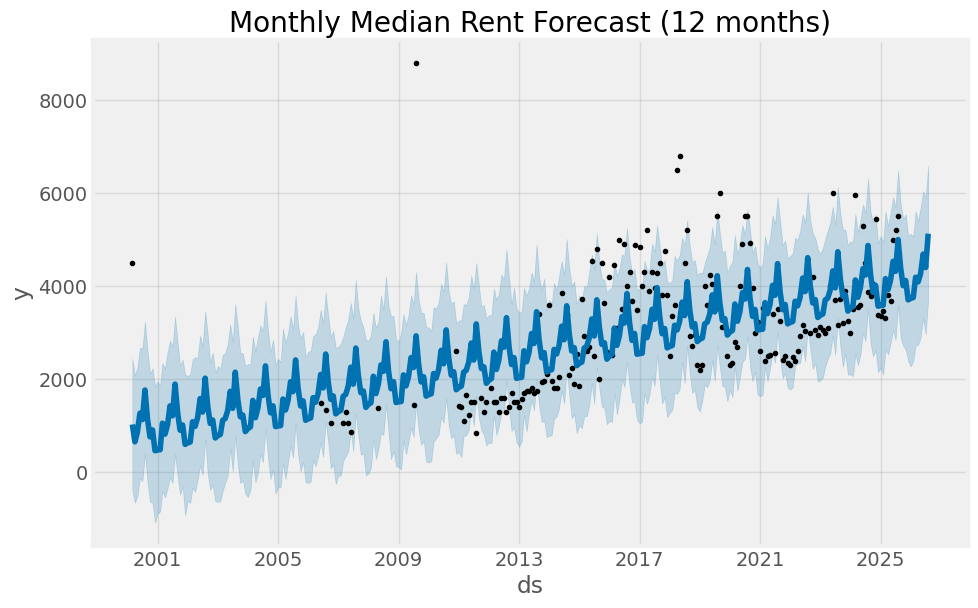


=== Cluster Counts ===
     KM_Cluster  DBSCAN_Cluster  Agglo_Cluster
-1          NaN            8517            NaN
 0       4662.0              25         4214.0
 1       1125.0              11         4486.0
 2       2720.0              12         1306.0
 3       1516.0              13           17.0
..          ...             ...            ...
 60         NaN              14            NaN
 61         NaN              11            NaN
 62         NaN              11            NaN
 63         NaN              16            NaN
 64         NaN              11            NaN

[66 rows x 3 columns]
Baseline RMSE: 12037.951183308158


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, IsolationForest
from sklearn.svm import SVR, SVC
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, roc_auc_score

# time-series & survival
from prophet import Prophet
from lifelines import CoxPHFitter

# 1) Load & combine data
df_j = pd.read_excel('rentalsJamaica.xlsx')
df_n = pd.read_excel('rentalsNYC.xlsx')
df  = pd.concat([df_j, df_n], ignore_index=True)

# 2) Parse dates & compute DOM
df['List Date']   = pd.to_datetime(df['List Date'],   errors='coerce')
df['Rented Date'] = pd.to_datetime(df['Rented Date'], errors='coerce')
df['DOM'] = (df['Rented Date'] - df['List Date']).dt.days

# 3) Define feature lists using actual columns
num_feats = [
    'Beds', 
    'Full Baths ',    # note trailing space
    'Half Baths', 
    'Total Square Feet',
    'DOM'
 ]
cat_feats = [
    'Neighborhood',
    'City',
    'Building',
    'Listing Type',
    'Property Type',
    'Status'
 ]

# Convert 'Studio' and other non-numeric to 0 in numeric columns
for col in num_feats:
    df[col] = df[col].replace('Studio', 0)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ensure all categorical columns are string type
for col in cat_feats:
    df[col] = df[col].astype(str)

# Drop rows where target is NaN
df_model = df[num_feats + cat_feats + ['Price']].dropna(subset=['Price'])
X = df_model[num_feats + cat_feats].fillna(0)
y = df_model['Price']

# 4) Preprocessing pipeline
preproc = ColumnTransformer([
    ('num', StandardScaler(), num_feats),
    ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), cat_feats),
])

# 5) Price prediction (regression)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
models_reg = {
    'OLS': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'RF': RandomForestRegressor(n_estimators=100),
    'SVR': SVR()
}

print("=== Price Prediction ===")
for name, m in models_reg.items():
    pipe = Pipeline([('prep', preproc), ('model', m)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    print(f"{name:<5} RMSE={np.sqrt(mean_squared_error(y_test, preds)):.2f}, R2={r2_score(y_test, preds):.3f}")

# 6) Fast‑rent classification (DOM ≤ 30 days)
df['FastRent'] = (df['DOM'] <= 30).astype(int)
Xc, yc = df[num_feats + cat_feats].fillna(0), df['FastRent']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2)
models_clf = {
    'Logistic': LogisticRegression(max_iter=1000),
    'RF': RandomForestClassifier(n_estimators=100),
    'SVC': SVC(probability=True)
}

print("\n=== FastRent Classification ===")
for name, m in models_clf.items():
    pipe = Pipeline([('prep', preproc), ('model', m)])
    pipe.fit(Xc_train, yc_train)
    preds = pipe.predict(Xc_test)
    prob  = pipe.predict_proba(Xc_test)[:,1]
    print(f"{name:<8} Acc={accuracy_score(yc_test, preds):.3f}, AUC={roc_auc_score(yc_test, prob):.3f}")

# 7) Survival analysis (Cox PH)
surv_cols = [col for col in num_feats if col != 'DOM'] + ['DOM', 'FastRent']
surv_df = df[surv_cols].dropna().rename(columns={'FastRent':'event'})
cph = CoxPHFitter()
cph.fit(surv_df, duration_col='DOM', event_col='event')
print("\n=== Cox PH Summary ===")
cph.print_summary()

# 8) Trend forecasting (monthly median Price)
ts = (
    df[['List Date','Price']]
    .dropna()
    .set_index('List Date')
    .resample('M')['Price']
    .median()
    .reset_index()
    .rename(columns={'List Date':'ds','Price':'y'})
)
m = Prophet(yearly_seasonality=True)
m.fit(ts)
future = m.make_future_dataframe(periods=12, freq='M')
forecast = m.predict(future)
fig = m.plot(forecast)
plt.title('Monthly Median Rent Forecast (12 months)')
plt.show()

# 9) Clustering
features = preproc.fit_transform(df[num_feats + cat_feats].fillna(0))
df['KM_Cluster']     = KMeans(n_clusters=4, random_state=2).fit_predict(features)
df['DBSCAN_Cluster'] = DBSCAN(eps=0.5, min_samples=10).fit_predict(features)
df['Agglo_Cluster']  = AgglomerativeClustering(n_clusters=4).fit_predict(features)

print("\n=== Cluster Counts ===")
print(df[['KM_Cluster','DBSCAN_Cluster','Agglo_Cluster']].apply(pd.Series.value_counts))

baseline_rmse = np.sqrt(np.mean((y_test - y_train.mean())**2))
print("Baseline RMSE:", baseline_rmse)


In [ ]:
# Log-transform regression for all models
print("\n=== Log-Transformed Price Prediction ===")
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)
for name, m in models_reg.items():
    pipe = Pipeline([('prep', preproc), ('model', m)])
    pipe.fit(X_train, y_train_log)
    preds_log = pipe.predict(X_test)
    preds = np.expm1(preds_log)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    print(f"{name:<5} RMSE={rmse:.2f}, R2={r2:.3f}")


=== Log-Transformed Price Prediction ===
OLS   RMSE=11471.78, R2=0.128
Ridge RMSE=10635.26, R2=0.251
Lasso RMSE=12534.17, R2=-0.041
RF    RMSE=10373.18, R2=0.287
SVR   RMSE=10416.71, R2=0.281


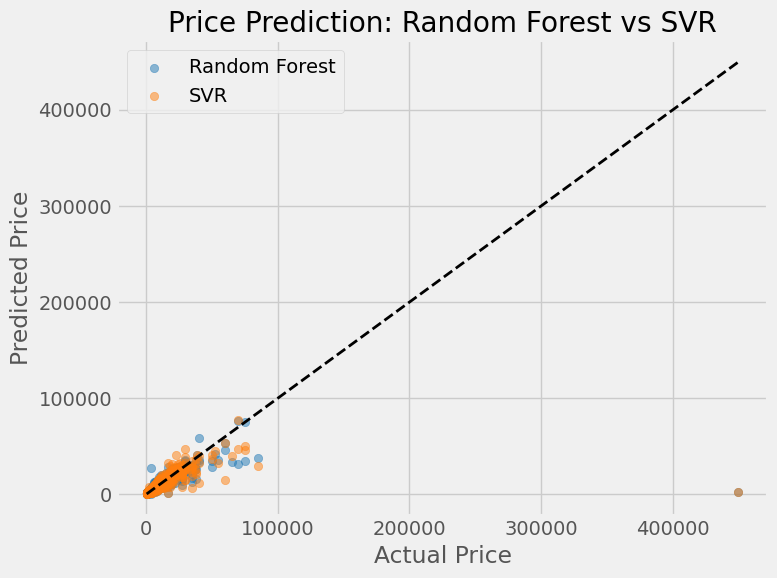

In [ ]:
# Graph of price prediction using RF and SVR
# Graph of price prediction using RF and SVR

# Fit RF and SVR on the full training set (log-transformed)
rf_pipe = Pipeline([('prep', preproc), ('model', RandomForestRegressor(n_estimators=100))])
svr_pipe = Pipeline([('prep', preproc), ('model', SVR())])

rf_pipe.fit(X_train, np.log1p(y_train))
svr_pipe.fit(X_train, np.log1p(y_train))

rf_preds = np.expm1(rf_pipe.predict(X_test))
svr_preds = np.expm1(svr_pipe.predict(X_test))

plt.figure(figsize=(8, 6))
plt.scatter(y_test, rf_preds, alpha=0.5, label='Random Forest', color='tab:blue')
plt.scatter(y_test, svr_preds, alpha=0.5, label='SVR', color='tab:orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Price Prediction: Random Forest vs SVR')
plt.legend()
plt.tight_layout()
plt.show()

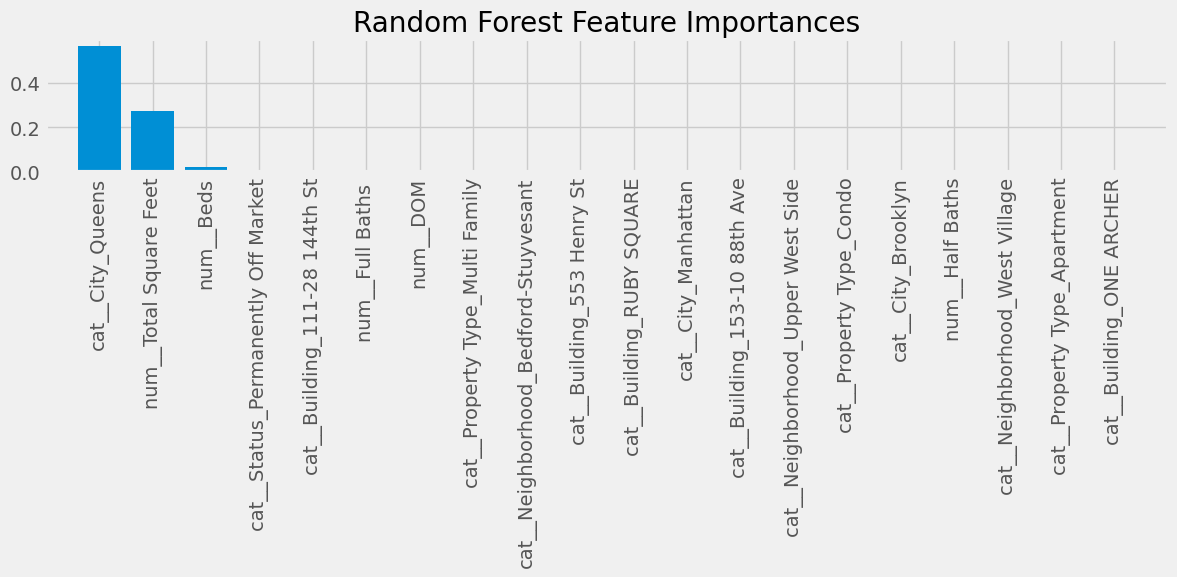

In [ ]:
# Feature importance
importances = rf_pipe.named_steps['model'].feature_importances_
feature_names = preproc.get_feature_names_out()
indices = np.argsort(importances)[::-1]

N = 20  # Show top 20 features
plt.figure(figsize=(12, 6))
plt.title("Random Forest Feature Importances")
plt.bar(range(N), importances[indices][:N], align="center")
plt.xticks(range(N), feature_names[indices][:N], rotation=90)
plt.xlim([-1, N])
plt.tight_layout()
plt.show()